# eCPA Flash — CO₂ – H₂O – NaCl

Notebook for phase equilibrium calculations using the **eCPA** (electrolyte Cubic-Plus-Association) equation of state for the CO₂ + H₂O + NaCl system. All implementation lives in the `ecpa/` Python package; this notebook drives calculations and visualisation.

**Key model features:**
- CPA EoS base with 4C association for H₂O (4 association sites)
- Cross-association between H₂O and CO₂ (H₂O acts as acceptor)
- Debye–Hückel electrostatics for Na⁺ / Cl⁻ ions
- Permittivity model for the dielectric constant (Kirkwood–Onsager)

**Sections:**
1. Setup — packages, guess table, EoS parameters, experimental data
2. CPA (salt-free) validation against experimental VLE data
3. eCPA single-point flash
4. Validation: ms→0 limit and tie-line invariance
5. Convergence scan over a 4-D (T, P, z_CO₂, ms) grid
6. Phase envelopes from scan bisection
7. Phase stability: Michelsen TPD analysis and stability maps

---
## 1. Setup

Import the `ecpa` package sub-modules and set algorithm switches.

- `FLASH_ALGO`: selects between the **Brent** flash (outer Brent loop over aqueous molality ms, inner ELV solve at fixed ms) and the **SSI** flash (successive substitution with Newton refinement).  Both converge to the same answer; Brent is more robust, SSI is faster when a good initial guess is available.
- `N_WORKERS`: controls the degree of parallelism for grid scans and phase-envelope bisection.  `None` auto-detects `cpu_count − 1`.

Load three external resources needed throughout the notebook:

| Resource | Variable | Purpose |
|----------|----------|---------|
| Guess table | `CPA_GROUPS`, `CPA_TEMPS`, `guess_table_fn` | Pre-computed ELV solutions on a (T, P) grid used as warm-start guesses for the flash solver |
| EoS parameters | `params` | Dict of eCPA constants (kij, association parameters, ion radii, …); can be overridden to explore parameter sensitivity |
| Experimental data | `EXP_DF`, `EXP_TEMPS` | Literature CO₂ solubility / VLE data for model validation |

In [1]:
import os
import pickle
import functools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ecpa.parameters  import make_params
from ecpa.guess_table import load_cpa_guess_table, make_guess_fn
from ecpa.exp_data    import load_exp_data
from ecpa.flash       import (flash_co2_h2o_salt_ssi, flash_co2_h2o_salt_1d,
                               get_flash_fn, build_continuation_cache)
from ecpa.scan        import run_flash_scan, print_scan_summary
from ecpa.envelope    import find_envelope_from_scan, build_cpa2_envelope
from ecpa.stability   import (ecpa_lnphi_aq, ecpa_lnphi_c,
                               ecpa_stability, ecpa_stability_flash)
from ecpa.utils       import print_flash_report, pct_diff, test_tieline_invariance
from ecpa.plotting    import (
    plot_cpa2_vs_exp,
    plot_combined_vs_exp,
    plot_convergence_map,
    plot_phase_envelope,
    plot_guess_table,
)

# ── Algorithm switches — adjust these to explore different flash implementations ──
FLASH_ALGO      = 'brent'  # 'ssi' or 'brent'
SSI_MAXITER     = 2000     # max SSI outer iterations (increase if convergence failures are high)
FORCE_RECOMPUTE = False    # set True to ignore cached results and recompute from scratch
N_WORKERS       = None     # None = auto-detect (cpu_count - 1); set an int to override
EXECUTOR        = 'process' # 'process' (safe default) or 'thread' (faster startup, experimental)

# Helper: build a flash callable with maxiter_ms bound for SSI
def make_flash_fn(algo=FLASH_ALGO, maxiter=SSI_MAXITER):
    fn = get_flash_fn(algo)
    return functools.partial(fn, maxiter_ms=maxiter) if algo == 'ssi' else fn


In [2]:
%%time
# ── Guess table ───────────────────────────────────────────────────────────────
PARQUET_PATH = "CPA_ELV_all.parquet"
CPA_GROUPS, CPA_TEMPS = load_cpa_guess_table(PARQUET_PATH)
guess_table_fn = make_guess_fn(CPA_GROUPS, CPA_TEMPS)

# ── EoS parameters ───────────────────────────────────────────────────────────
params = make_params()

# ── Experimental data ────────────────────────────────────────────────────────
EXP_DF, EXP_TEMPS = load_exp_data(data_dir="EXP/CO2-WATER",
                                   parquet_path="CO2_WATER_exp.parquet")

print(f"Guess table: {len(CPA_TEMPS)} temperature slabs")
print(f"Exp data:    {len(EXP_DF)} rows, {len(EXP_TEMPS)} temperatures")

Loaded CO2_WATER_exp.parquet  (631 rows)
Guess table: 251 temperature slabs
Exp data:    631 rows, 35 temperatures
CPU times: user 189 ms, sys: 135 ms, total: 325 ms
Wall time: 286 ms


In [3]:
T_SELECT = EXP_TEMPS

---
## 2. CPA (salt-free) vs. Experimental Data

**CPA** is the salt-free version of the model (CO₂ + H₂O only, no electrolytes). Comparing against experimental VLE data confirms that the base EoS is well-calibrated before adding salt effects.

The plot overlays:
- **Experimental data** (literature CO₂ solubility in water at multiple temperatures)
- **CPA flash** predictions using the guess-table warm-start strategy

Good agreement here validates the association and cross-association parameters (ε/k, κ) and the binary interaction parameters (kij, Sij) before salt is introduced.

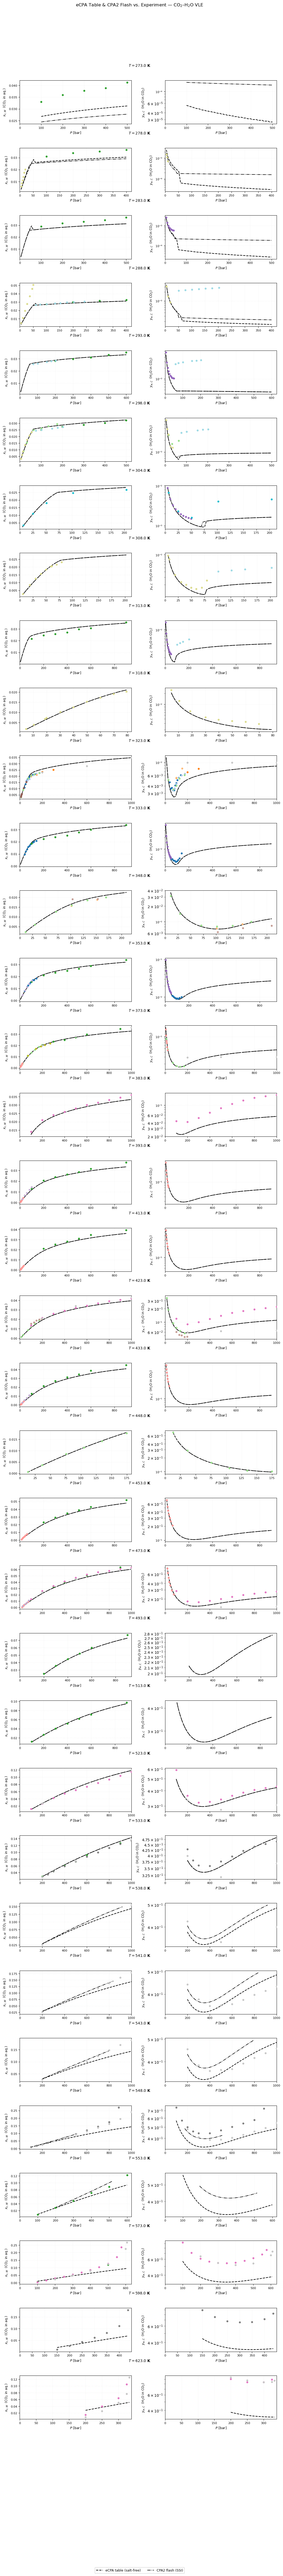

CPU times: user 5.19 s, sys: 417 ms, total: 5.61 s
Wall time: 35.9 s


In [4]:
%%time
# eCPA table guess + CPA flash overlaid on experimental data
fig_combined = plot_combined_vs_exp(
    T_list      = T_SELECT,
    exp_df      = EXP_DF,
    CPA_GROUPS  = CPA_GROUPS,
    CPA_TEMPS   = CPA_TEMPS,
    N_P         = 60,
    n_workers   = 8,
    P_MAX       = 1000.0,
    save_path   = None,   # e.g. "figures/combined_vs_exp.png"
)
plt.show()

Compare the **SSI flash** result above with the **Brent flash** at the same conditions. Both algorithms must give identical phase compositions and β — this cross-check verifies that neither implementation has a bug. Minor numerical differences (< 0.01%) are expected from different convergence tolerances.

---
## 3. eCPA Single-Point Flash

A **two-phase flash** at a single (T, P, z_CO₂, ms) condition splits the feed into:
- **Aqueous phase** — mostly H₂O + dissolved CO₂ + Na⁺ + Cl⁻, characterised by ms\_aq (equilibrium molality)
- **CO₂-rich phase** — mostly CO₂ + trace H₂O, no salt

**Feed specification:**
- `z_co2` — overall CO₂ mole fraction (relative to CO₂ + H₂O; salt is added as a separate quantity)
- `m_tot` — total salt molality of the water basis [mol NaCl / kg H₂O]
- `T`, `P` — temperature [K] and pressure [bar]

The output includes phase compositions (x1w, x4w, x1c, x4c), compressibility factors (Z\_aq, Z\_c), phase fractions (β), and convergence diagnostics.

In [5]:
%%time
T_pt, P_pt, z_pt, ms_pt = 398.0, 100.0, 0.5, 0.5

_kw = {'maxiter_ms': SSI_MAXITER} if FLASH_ALGO == 'ssi' else {}
out_ssi = get_flash_fn(FLASH_ALGO)(
    T=T_pt, P_bar=P_pt, z_co2=z_pt, m_tot=ms_pt,
    guess_table_fn=guess_table_fn, params=params,
    verbose=True, **_kw,
)
print_flash_report(out_ssi)


  cache : 201 pts  ms = 0.000 → 20.000  avg nfev = 17.9
  scan  : 206 pts  avg nfev = 14.0  avg resnorm = 2.24e-14  bracket ms = [0.5000, 0.6000]
  result: ms_aq = 0.5192  resnorm = 7.47e-13  OK

================ FLASH RESULT ================

  T = 398.00 K          P = 100.00 bar
  z_CO2 (feed)  =  50.00%    m_tot = 0.5000 mol/kg
  n_salt (basis)= 4.5000e-03 mol

-------- Phase Split --------
  beta  (CO2-rich fraction) =  50.88%
  N_aq  = 4.9564e-01 mol     N_c = 5.1336e-01 mol

-------- Aqueous Phase --------
  ms_aq = 0.5192 mol/kg    Z_aq = 0.060095
  rho   = 929.6 kg/m³    (5.0286e+04 mol/m³)
  V_aq  = 9.8565e-06 m³    S_aq =   6.60%
  x_H2O =  97.16%   x_CO2 =   1.03%
  x_Na+ =   0.91%   x_Cl- =   0.91%
  n_H2O = 0.4816 mol   n_CO2 = 0.0051 mol
  n_Na+ = 0.0045 mol   n_Cl- = 0.0045 mol

-------- CO2-Rich Phase --------
  Z_c   = 0.820615
  rho   = 158.6 kg/m³    (3.6825e+03 mol/m³)
  V_c   = 1.3940e-04 m³    S_c  =  93.40%
  x_H2O =   3.59%   x_CO2 =  96.41%
  n_H2O = 0.0184 mo

In [6]:
%%time
# Brent flash at the same point for comparison
out_brent = flash_co2_h2o_salt_1d(
    T=T_pt, P_bar=P_pt, z_co2=z_pt, m_tot=ms_pt,
    guess_table_fn=guess_table_fn, params=params,
)
print_flash_report(out_brent)


================ FLASH RESULT ================

  T = 398.00 K          P = 100.00 bar
  z_CO2 (feed)  =  50.00%    m_tot = 0.5000 mol/kg
  n_salt (basis)= 4.5000e-03 mol

-------- Phase Split --------
  beta  (CO2-rich fraction) =  50.88%
  N_aq  = 4.9564e-01 mol     N_c = 5.1336e-01 mol

-------- Aqueous Phase --------
  ms_aq = 0.5192 mol/kg    Z_aq = 0.060095
  rho   = 929.6 kg/m³    (5.0286e+04 mol/m³)
  V_aq  = 9.8565e-06 m³    S_aq =   6.60%
  x_H2O =  97.16%   x_CO2 =   1.03%
  x_Na+ =   0.91%   x_Cl- =   0.91%
  n_H2O = 0.4816 mol   n_CO2 = 0.0051 mol
  n_Na+ = 0.0045 mol   n_Cl- = 0.0045 mol

-------- CO2-Rich Phase --------
  Z_c   = 0.820615
  rho   = 158.6 kg/m³    (3.6825e+03 mol/m³)
  V_c   = 1.3940e-04 m³    S_c  =  93.40%
  x_H2O =   3.59%   x_CO2 =  96.41%
  n_H2O = 0.0184 mol   n_CO2 = 0.4949 mol

-------- Mass Balance --------
  H2O : 5.0000e-01 mol  (target 5.0000e-01)
  CO2 : 5.0000e-01 mol  (target 5.0000e-01)
  salt: 4.5000e-03  mol  (target 4.5000e-03)

------

---
## 4. Validation

Two consistency checks confirm the eCPA flash is thermodynamically self-consistent.

### 4.1  ms → 0 limit: eCPA vs. CPA

As salt molality → 0, eCPA must reduce exactly to CPA (the salt-free model). This checks that the Debye–Hückel and permittivity terms vanish correctly, and that the ELV solver does not introduce numerical drift when ions are absent. We run eCPA at ms = 10⁻⁴ mol/kg and compare against the CPA reference.

In [7]:
%%time
import CPA

T_test, P_test, z_test = 398.0, 100.0, 0.5

# ── CPA salt-free reference ─────────────────────────────────────────────────
res_cpa2 = CPA.flash_co2_h2o_tpz(T=T_test, P_bar=P_test, z_co2=z_test)
tie      = res_cpa2['tie']

# ── eCPA ms→0 via continuation cache (Brent approach) ───────────────────────
base_guess = guess_table_fn(T_test, P_test)
cache = build_continuation_cache(T_test, P_test, base_guess,
                                 ms_max=0.1, params=params, dm=0.05)
sol0 = cache[0][1]
Zw_br, x1w_br, _, Zc_br, x1c_br = sol0[:5]

# ── eCPA ms→0 via SSI (tiny ms = 1e-4) ───────────────────────────────────────
out_ssi0 = flash_co2_h2o_salt_ssi(
    T=T_test, P_bar=P_test, z_co2=z_test, m_tot=1e-4,
    guess_table_fn=guess_table_fn, params=params, maxiter_ms=SSI_MAXITER,
)
Zw_ssi = out_ssi0['Z_aq'];  Zc_ssi = out_ssi0['Z_c']
x1w_ssi = out_ssi0['x_aq']['x1w'];  x1c_ssi = out_ssi0['x_c']['x1c']

print(f'ms=0 comparison  (T={T_test}K  P={P_test}bar  z_CO2={z_test})')
print(f"{'':20s}  {'CPA':>10s}  {'eCPA Brent':>12s}  {'eCPA SSI':>10s}")
print('-' * 65)
for label, v_cpa2, v_br, v_ssi in [
    # CPA: x=aqueous [CO2,H2O], y=CO2-rich [CO2,H2O]; Z[0]=aq, Z[1]=CO2-rich
    ('Z_aq',     tie['Z'][0],  Zw_br, Zw_ssi),
    ('Z_c',      tie['Z'][1],  Zc_br, Zc_ssi),
    ('x_H2O_aq', tie['x'][1],  x1w_br, x1w_ssi),
    ('x_CO2_aq', tie['x'][0],  1-x1w_br, 1-x1w_ssi),
    ('x_H2O_c',  tie['y'][1],  x1c_br, x1c_ssi),
    ('x_CO2_c',  tie['y'][0],  1-x1c_br, 1-x1c_ssi),
]:
    d_br  = pct_diff(v_br, v_cpa2)
    d_ssi = pct_diff(v_ssi, v_cpa2)
    print(f'  {label:<18s}  {v_cpa2:10.6f}  {v_br:10.6f} ({d_br:+6.3f}%)'
          f'  {v_ssi:10.6f} ({d_ssi:+6.3f}%)')


ms=0 comparison  (T=398.0K  P=100.0bar  z_CO2=0.5)
                            CPA    eCPA Brent    eCPA SSI
-----------------------------------------------------------------
  Z_aq                  0.059109    0.059112 (+0.005%)    0.059112 (+0.005%)
  Z_c                   0.820404    0.820376 (-0.003%)    0.820376 (-0.003%)
  x_H2O_aq              0.988437    0.988437 (+0.000%)    0.988433 (-0.000%)
  x_CO2_aq              0.011563    0.011563 (-0.001%)    0.011567 (+0.028%)
  x_H2O_c               0.036613    0.036608 (-0.015%)    0.036608 (-0.015%)
  x_CO2_c               0.963387    0.963392 (+0.001%)    0.963392 (+0.001%)
CPU times: user 33.6 ms, sys: 1.1 ms, total: 34.7 ms
Wall time: 34.7 ms


### 4.2  Tie-Line Invariance

At fixed (T, P), a two-phase system has a unique **tie line**: the equilibrium phase compositions (x\_aq, x\_c) are independent of the overall feed composition z_CO₂. Only the **phase fraction** β changes with z_CO₂.

This test sweeps z_CO₂ from 0.05 to 0.99 and verifies that x1w, x1c, and ms\_aq are constant across all feeds. Any variation would indicate a bug in the mass-balance or ELV solver.

In [8]:
%%time
results_tl = test_tieline_invariance(
    T=398.0, P_bar=100.0,
    z_co2_values=np.array([0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]),
    m_tot=0.5,
    guess_table_fn=guess_table_fn,
    params=params,
    flash_fn=make_flash_fn(FLASH_ALGO, SSI_MAXITER),
    verbose=True,
)


Tie-line invariance test: T=398.0 K, P=100.0 bar, m_tot=0.5 mol/kg
Varying z_co2 over 9 feed compositions

  z_co2   z_H2O    beta   x_H2O_aq   x_CO2_aq    ms_aq   x_H2O_c   x_CO2_c                 status
-------------------------------------------------------------------------------------------------------
  z_co2=0.001 failed: No sign change found in water residual scan. This may indicate a single-phase state at this T, P.
 0.0010  0.9990     ---        ---        ---      ---       ---       ---                 failed
  z_co2=0.010 failed: No sign change found in water residual scan. This may indicate a single-phase state at this T, P.
 0.0100  0.9900     ---        ---        ---      ---       ---       ---                 failed
 0.0500  0.9500  0.0407   0.972168   0.010306   0.5008  0.035959  0.964041              converged
 0.2500  0.7500  0.2478   0.971996   0.010294   0.5061  0.035952  0.964048              converged
 0.5000  0.5000  0.5088   0.971575   0.010267   0.5192  0.0

Visualise the scan results as a convergence map. Each tile shows whether the flash converged (green), failed due to being outside the guess-table P range or single-phase (grey/yellow), or failed for other reasons (red). This guides where the phase envelope (Section 6) can be reliably traced.

---
## 5. Convergence Scan

Run the flash over a 4-D grid of conditions to map where the solver converges:

| Dimension | Values |
|-----------|--------|
| T | 283 – 533 K (every 25 K) |
| P | 1 – 1500 bar (20 log-spaced points) |
| z_CO₂ | 0.1, 0.3, 0.5, 0.7, 0.9 |
| ms | 0.5, 1.0, 2.0 mol/kg |

Results are cached to Parquet so rerunning the notebook is instant when `FORCE_RECOMPUTE = False`. The convergence map (next cell) shows which (T, P) regions are reliable and which are near single-phase boundaries or outside the guess-table coverage.

In [9]:
# ── Grid definition ───────────────────────────────────────────────────────────
T_values     = np.arange(283, 534, 25)                  # K
P_values     = np.logspace(0, np.log10(1500), 20)       # bar
ms_values    = [0.5, 1.0, 2.0]                          # mol/kg
z_co2_values = np.round(np.linspace(0.1, 0.9, 5), 2)   # feed mole fractions

print(f"Grid: {len(T_values)} T × {len(P_values)} P × "
      f"{len(ms_values)} ms × {len(z_co2_values)} z_CO2 = "
      f"{len(T_values)*len(P_values)*len(ms_values)*len(z_co2_values)} points")

Grid: 11 T × 20 P × 3 ms × 5 z_CO2 = 3300 points


In [10]:
%%time
df_results = run_flash_scan(
    guess_table_fn      = guess_table_fn,
    params              = params,
    CPA_GROUPS          = CPA_GROUPS,
    CPA_TEMPS           = CPA_TEMPS,
    T_values            = T_values,
    P_values            = P_values,
    ms_values           = ms_values,
    z_co2_values        = z_co2_values,
    flash_algo          = FLASH_ALGO,
    ssi_maxiter         = SSI_MAXITER,
    scan_file           = 'results/scan_results.parquet',
    use_cpa2_precheck   = False,
    use_stability_check = True,
    force_recompute     = FORCE_RECOMPUTE,
    n_workers           = N_WORKERS,
    executor            = EXECUTOR,
)
print_scan_summary(df_results)


Loaded cached scan: results/scan_results.parquet
  3300 records | 2551 converged (77.3%)

Error type                      Count       %  Interpretation
--------------------------------------------------------------------------------
  none                           2551   77.3%  converged successfully
  out_of_range                    705   21.4%  outside table P range or CPA single-phase
  no_sign_change                   44    1.3%  Brent + SSI + CPA all uncertain — genuine flash failure

Genuinely concerning failures: 0

Boundary / single-phase-classified points (44 total):
   z_co2      T        P   ms  error_type
    0.10    533  1500.00  0.5  no_sign_change
    0.90    358     1.00  0.5  no_sign_change
    0.90    383     2.16  0.5  no_sign_change
    0.90    408     4.66  0.5  no_sign_change
    0.90    433     6.85  0.5  no_sign_change
    0.90    433    10.07  0.5  no_sign_change
    0.90    458    14.80  0.5  no_sign_change
    0.90    458    21.74  0.5  no_sign_change
    0.

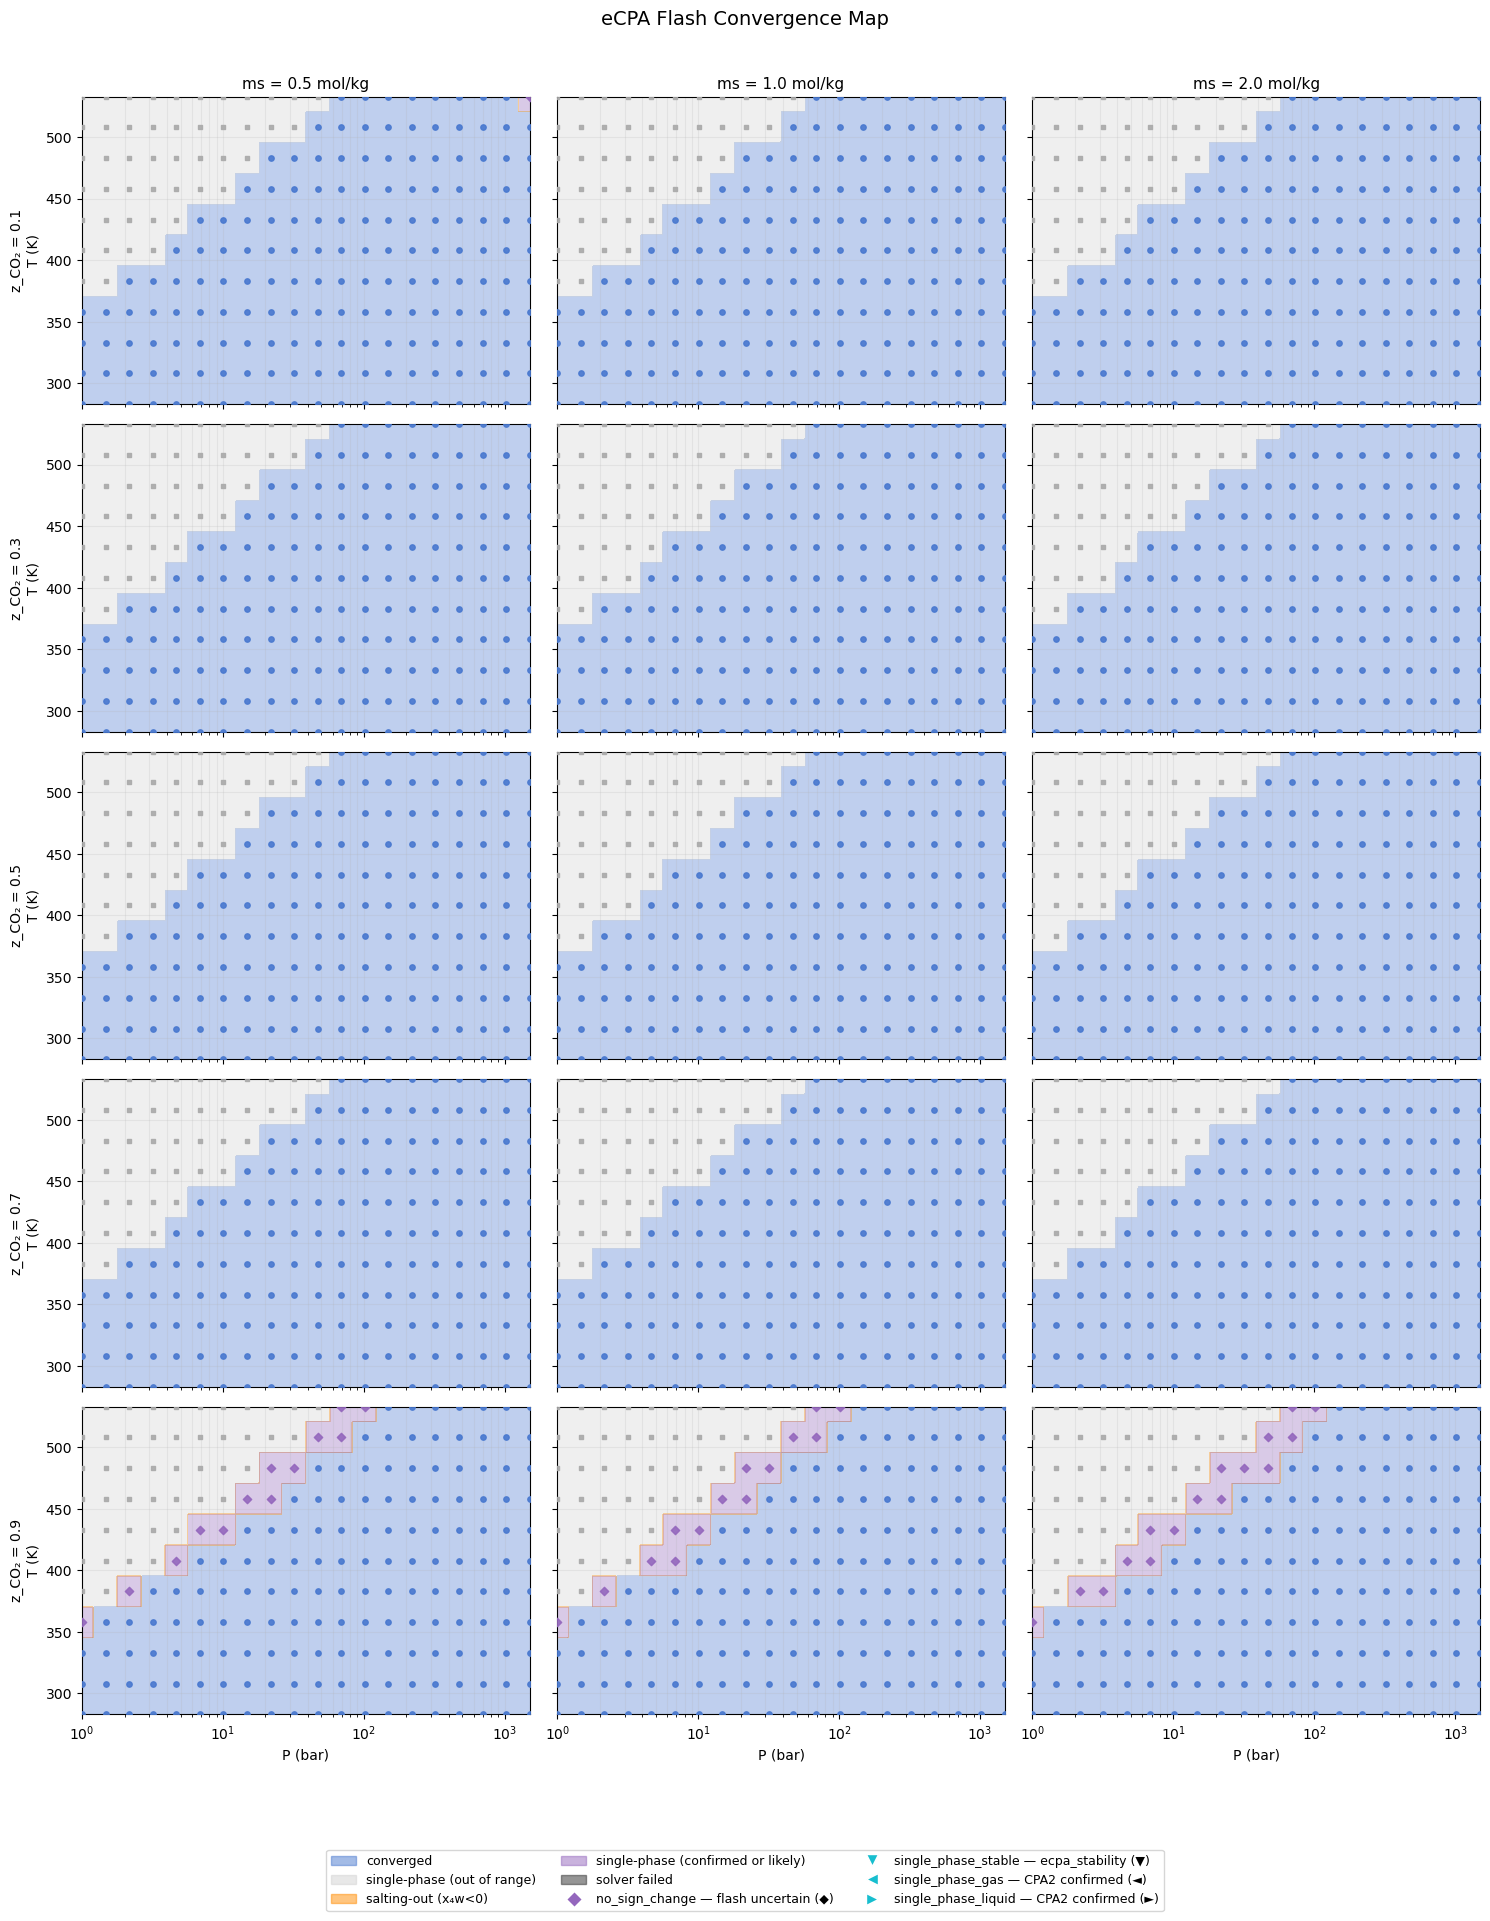

CPU times: user 2.39 s, sys: 45.2 ms, total: 2.44 s
Wall time: 2.44 s


In [11]:
%%time
fig_conv = plot_convergence_map(
    df_results   = df_results,
    z_co2_values = z_co2_values,
    ms_values    = ms_values,
    save_path    = None,   # e.g. "figures/convergence_map.png"
)
plt.show()

---
## 6. Phase Envelopes

### 6.1  eCPA envelope from scan (bisection)

The **phase envelope** is the locus of (T, P) bubble and dew points — the boundary between single-phase and two-phase regions for a given feed (z_CO₂, ms).

`find_envelope_from_scan` extracts the envelope by bisecting between converged and non-converged points in the 4-D scan:
- **P_lo** (bubble point) — bisect between the lowest converged P and the highest non-converged P below it
- **P_hi** (upper miscibility pressure) — bisect between the highest converged P and the lowest non-converged P above it

Bisection is parallelised over (z_CO₂, ms, T) groups. Results are cached to a pickle file.

In [12]:
%%time
envelopes_ecpa = find_envelope_from_scan(
    df_results      = df_results,
    z_co2_values    = z_co2_values,
    ms_values       = ms_values,
    T_values        = T_values,
    guess_table_fn  = guess_table_fn,
    params          = params,
    CPA_GROUPS      = CPA_GROUPS,
    CPA_TEMPS       = CPA_TEMPS,
    flash_algo      = FLASH_ALGO,
    n_bisect        = 25,
    cache_file      = 'results/envelope_ecpa.pkl',
    force_recompute = FORCE_RECOMPUTE,
    n_workers       = N_WORKERS,
)


Resuming eCPA envelope from results/envelope_ecpa.pkl

eCPA envelope: 165 points total | 165 cached | 0 NaN (no data) | 0 to bisect | 9 workers

eCPA envelope complete in 0.0s
CPU times: user 11.8 ms, sys: 2.01 ms, total: 13.8 ms
Wall time: 12.8 ms


### 6.2  CPA salt-free envelope (parallel)

Compute the salt-free (ms = 0) envelope using **CPA** directly. This serves as a reference: adding NaCl salt salts out CO₂ (reduces its solubility), which should narrow/shift the two-phase region relative to the salt-free case. The eCPA envelopes at different ms values should bracket the CPA result.

In [13]:
%%time
T_envelope_cpa2 = np.arange(283, 534, 25)

envelopes_cpa2 = build_cpa2_envelope(
    T_values        = T_envelope_cpa2,
    z_co2_values    = z_co2_values,
    params_cpa2     = params,
    n_workers       = 8,
    cache_file      = "results/envelope_cpa2.pkl",
    force_recompute = FORCE_RECOMPUTE,
)

Resuming CPA envelope from results/envelope_cpa2.pkl  (55 pts cached)
Total: 55  cached: 55  remaining: 0
CPU times: user 2.94 ms, sys: 1.41 ms, total: 4.35 ms
Wall time: 3.76 ms


### 6.3  Phase envelope plot

Overlay eCPA envelopes (at ms = 0.5, 1.0, 2.0 mol/kg) and the CPA salt-free reference for each z_CO₂ value. Each envelope traces P_lo (lower boundary, bubble-point-like) and P_hi (upper miscibility pressure) as a function of temperature.

**Expected trend:** increasing salinity should raise the lower envelope (bubble point) and lower P_hi — salt reduces CO₂ solubility so two-phase conditions persist over a narrower P window.

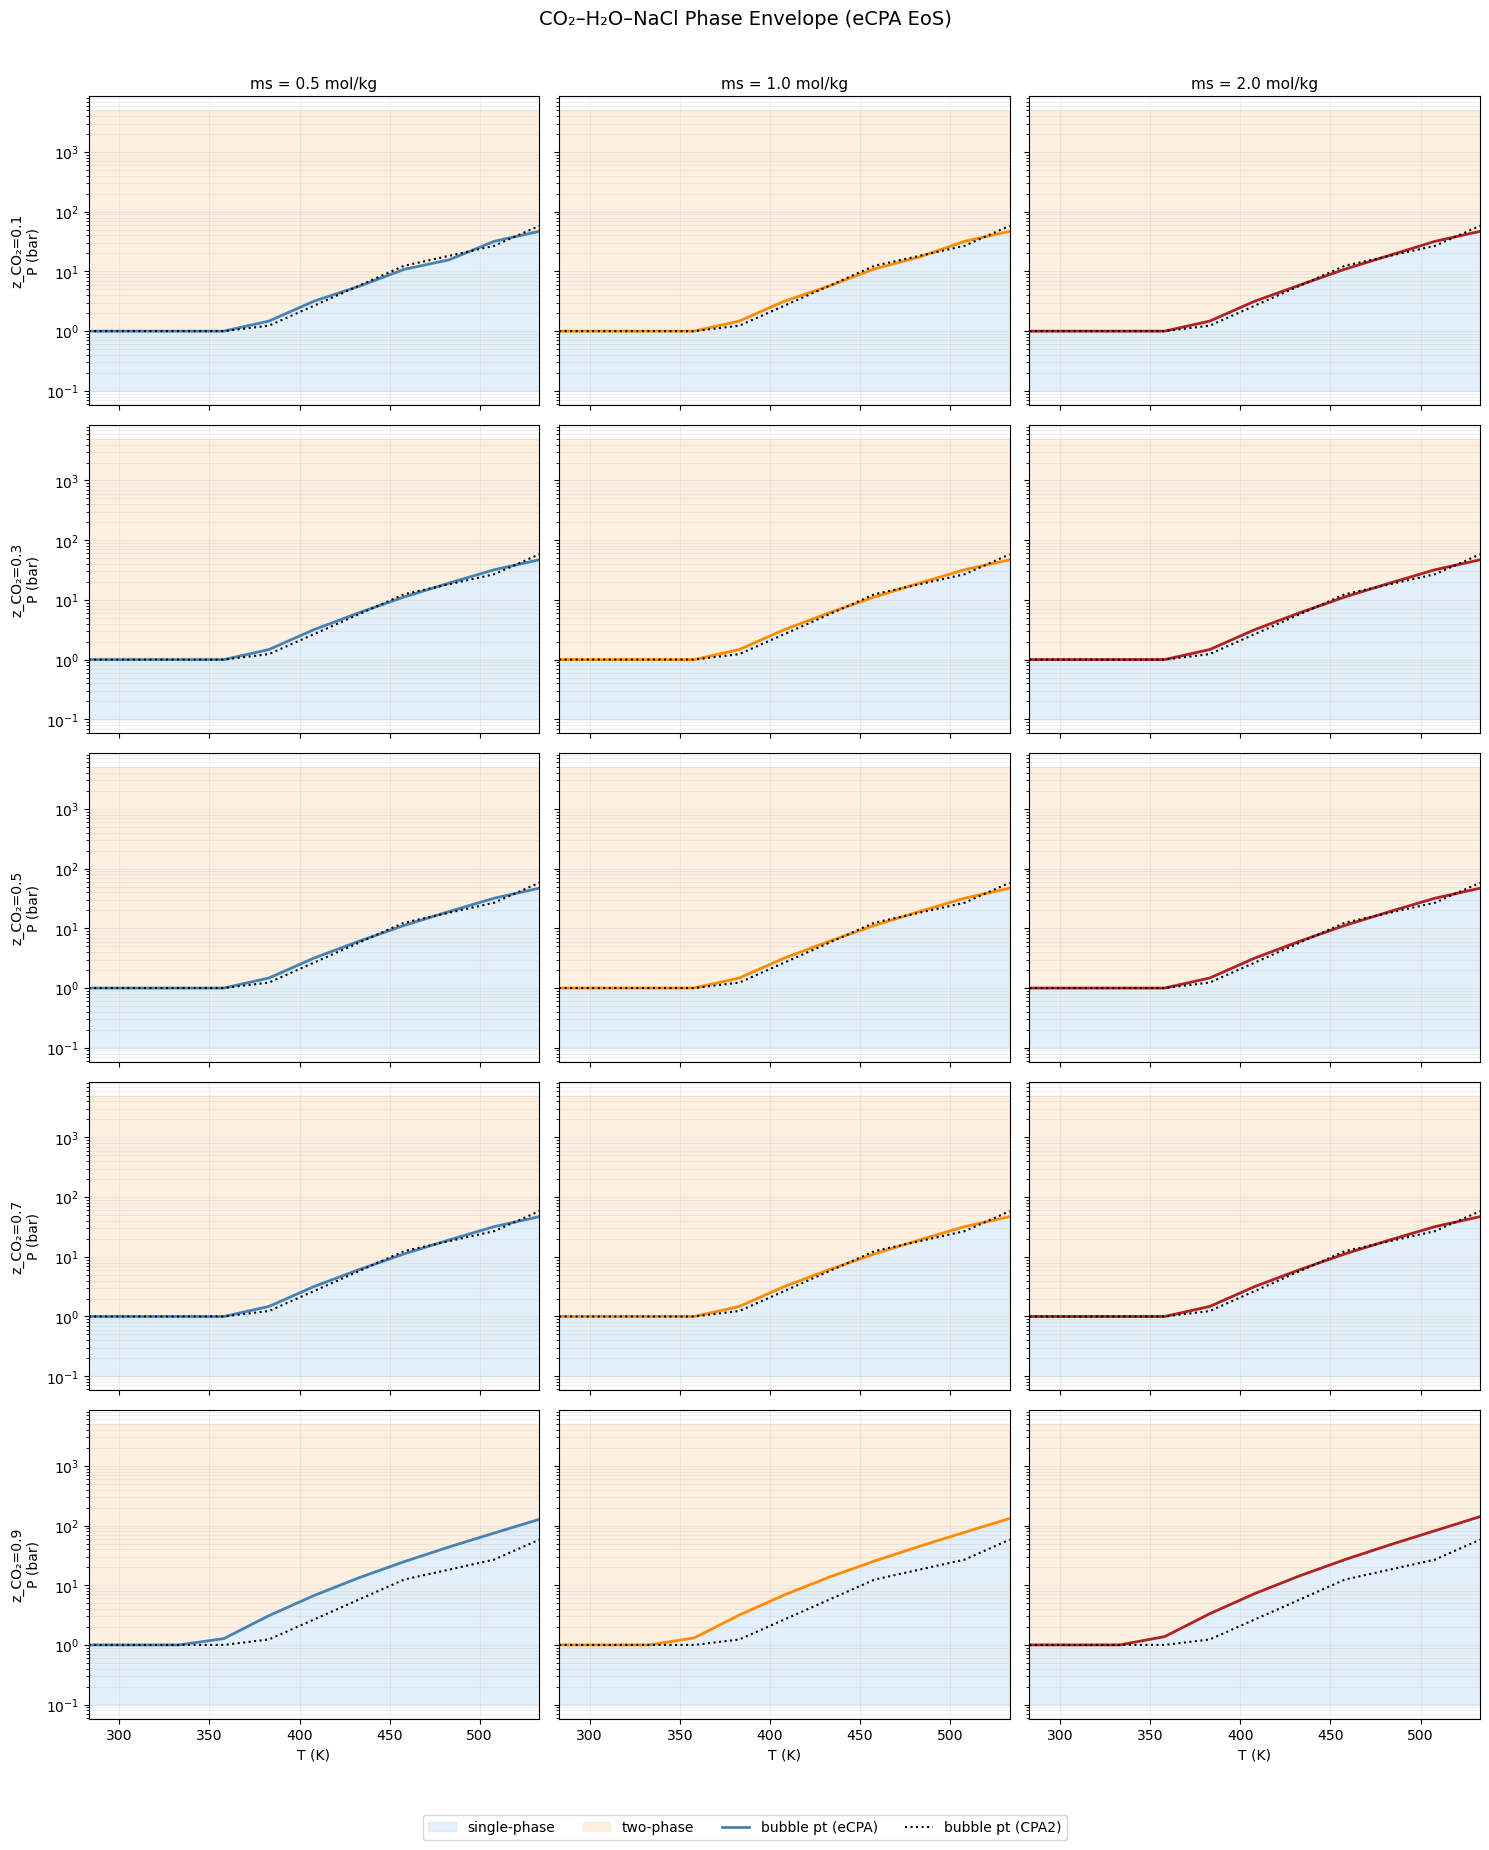

CPU times: user 1.93 s, sys: 62.2 ms, total: 1.99 s
Wall time: 1.99 s


In [14]:
%%time
ms_colors = ["steelblue", "darkorange", "firebrick"]

fig_env = plot_phase_envelope(
    envelopes_ecpa = envelopes_ecpa,
    z_co2_values   = z_co2_values,
    ms_values      = ms_values,
    envelopes_cpa2 = envelopes_cpa2,
    ms_colors      = ms_colors,
    save_path      = None,   # e.g. "figures/phase_envelope.png"
)
plt.show()

---
## 7. Phase Stability

Phase stability is checked using the **Michelsen tangent-plane distance (TPD)** test. For a feed (z_CO₂, ms) at (T, P), the system is **single-phase stable** if and only if the Gibbs energy surface is convex — i.e., no trial phase composition w gives a lower Gibbs energy than the feed.

**Algorithm:** SSI (successive substitution) on the stationary conditions of TPD. Two trial phases are tested from extreme compositions:
1. **CO₂-rich trial** — start from nearly-pure CO₂ (x1c ≈ 0.01)
2. **Aqueous trial** — start from nearly-pure brine (x1w ≈ 0.98)

The SSI update rule is:
$$W_i^{(k+1)} = \exp\left(d_i - \ln\hat\phi_i(W^{(k)})\right), \quad \Sigma W = \sum_i W_i$$

If $\Sigma W > 1$ at convergence, TPD < 0, and the system is **two-phase unstable**. The CO₂-rich EoS is used as the reference for both trials (the aqueous EoS is invalid at high z_CO₂).

### 7.1  Single-point stability test

In [15]:
%%time
from ecpa.stability import (ecpa_stability, ecpa_stability_flash,
                             ecpa_lnphi_aq, ecpa_lnphi_c, stability_map, stability_ms_scan)

T_stab, P_stab, z_stab, ms_stab = 398.0, 100.0, 0.5, 0.5

stab = ecpa_stability(z_stab, ms_stab, T_stab, P_stab, params)
print(f'Stability at T={T_stab} K, P={P_stab} bar, z_CO2={z_stab}, ms={ms_stab} mol/kg:')
for k, v in stab.items():
    print(f'  {k:15s}: {v}')

Stability at T=398.0 K, P=100.0 bar, z_CO2=0.5, ms=0.5 mol/kg:
  stable         : False
  tpd_min        : -1.068569568129254
  trial_type     : both
  x1c_trial      : 0.023566743898677592
  x1w_trial      : 0.9869243570820011
  sum_W_c        : 2.068569568129254
  sum_W_aq       : 1.386499558243338
  message        : Both CO₂-rich and aqueous trials indicate instability
  co2_ref_x0     : [0.12096352 0.32617595]
  aq_ref_x0      : [0.12096352 0.32617595]
CPU times: user 7.6 ms, sys: 471 μs, total: 8.07 ms
Wall time: 7.69 ms


Print the numerical $\Sigma W$ values for both trials at each pressure — useful for diagnosing the stability boundary and checking for solver artefacts (e.g. flat regions or NaN values that would indicate failed EoS evaluations).

### 7.2  Fugacity equality check at equilibrium

At a two-phase equilibrium, the **fugacity** of each component must be equal in both phases:
$$\ln f_i^{aq} = \ln f_i^c \quad \Leftrightarrow \quad \ln x_i^{aq} + \ln\hat\phi_i^{aq} = \ln x_i^c + \ln\hat\phi_i^c$$

Note: `ecpa_lnphi_*` returns $\ln\hat\phi_i$ (the fugacity *coefficient*), not the fugacity itself — so we must add $\ln x_i$ before comparing phases.

This cell evaluates lnφ at the flash equilibrium compositions and checks that the residuals $|\ln f_i^{aq} - \ln f_i^c|$ are ≈ 10⁻¹⁰ (numerical noise level). Large residuals would indicate a bug in the lnφ routines or a mismatch between the flash and stability EoS implementations. The equilibrium molality `ms_aq` from the flash output (not the feed `m_tot`) must be used for the aqueous phase.

In [16]:
%%time
# Equilibrium condition: ln(xᵢ · φᵢ) must be equal in both phases.
# ecpa_lnphi_* return ln(φᵢ), so we must add ln(xᵢ) before comparing.
# We also use ms_aq from the flash (equilibrium aqueous molality), not m_tot.

Mw_H2O   = 0.018015                  # kg/mol
ms_aq_eq = out_ssi['ms_aq']          # equilibrium aqueous molality
x1w_eq   = out_ssi['x_aq']['x1w']   # H2O mole fraction in aqueous
x1c_eq   = out_ssi['x_c']['x1c']    # H2O mole fraction in CO2-rich

# Aqueous: x2w = x3w (Na⁺, Cl⁻),  x4w = CO2
x2w_eq = x1w_eq * ms_aq_eq * Mw_H2O
x4w_eq = 1.0 - x1w_eq - 2.0 * x2w_eq

# CO2-rich: only H2O + CO2
x4c_eq = 1.0 - x1c_eq

lnphi1w, lnphi4w = ecpa_lnphi_aq(x1w_eq, ms_aq_eq, T_stab, P_stab, params)
lnphi1c, lnphi4c = ecpa_lnphi_c(x1c_eq, T_stab, P_stab, params)

# ln-fugacity = lnphi + ln(x)
lnf1_aq = lnphi1w + np.log(x1w_eq)
lnf1_c  = lnphi1c + np.log(x1c_eq)
lnf4_aq = lnphi4w + np.log(x4w_eq)
lnf4_c  = lnphi4c + np.log(x4c_eq)

print(f'Fugacity equality check  (ms_aq = {ms_aq_eq:.4f} mol/kg from flash)')
print()
print(f'  {"":5s}  {"lnφ (aq)":>10}  {"ln(x) (aq)":>11}  '
      f'{"lnf (aq)":>10}  |  '
      f'{"lnφ (c)":>10}  {"ln(x) (c)":>10}  '
      f'{"lnf (c)":>10}  |  |Δlnf|')
print('  ' + '-'*90)
for label, lp_aq, lx_aq, lf_aq, lp_c, lx_c, lf_c in [
    ('H2O', lnphi1w, np.log(x1w_eq), lnf1_aq, lnphi1c, np.log(x1c_eq), lnf1_c),
    ('CO2', lnphi4w, np.log(x4w_eq), lnf4_aq, lnphi4c, np.log(x4c_eq), lnf4_c),
]:
    print(f'  {label:<5s}  {lp_aq:10.6f}  {lx_aq:11.6f}  '
          f'{lf_aq:10.6f}  |  '
          f'{lp_c:10.6f}  {lx_c:10.6f}  '
          f'{lf_c:10.6f}  |  {abs(lf_aq - lf_c):.2e}')


Fugacity equality check  (ms_aq = 0.5192 mol/kg from flash)

           lnφ (aq)   ln(x) (aq)    lnf (aq)  |     lnφ (c)   ln(x) (c)     lnf (c)  |  |Δlnf|
  ------------------------------------------------------------------------------------------
  H2O     -3.762792    -0.028837   -3.791629  |   -0.465582   -3.326047   -3.791629  |  1.04e-10
  CO2      4.373350    -4.580317   -0.206967  |   -0.169098   -0.036596   -0.205694  |  1.27e-03
CPU times: user 2.49 ms, sys: 28 μs, total: 2.51 ms
Wall time: 2.51 ms


### 7.3  Sum_W vs. pressure (fixed T, z_CO₂, ms)

Scan $\Sigma W$ from both trials across a range of pressures at fixed (T, z_CO₂, ms). This shows how the stability margin evolves with P:

- $\Sigma W > 1$ → two-phase unstable (system will split)
- $\Sigma W = 1$ → stability boundary (bubble/dew point)
- $\Sigma W < 1$ → single-phase stable

The P-scan uses **warm-starting**: the EoS solver solution from each P step is passed as the starting guess for the next, keeping the solver on the same solution branch and preventing discontinuous jumps.

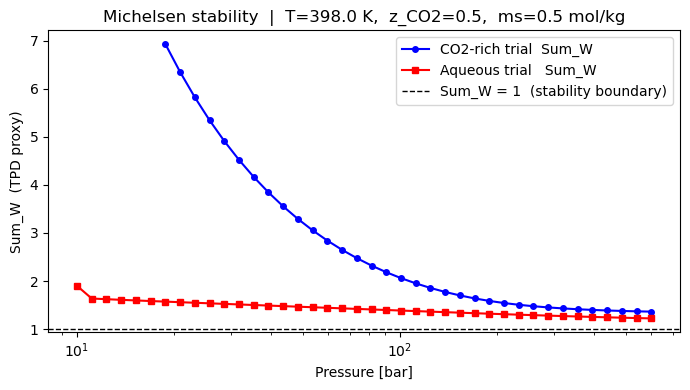

CPU times: user 2.59 s, sys: 58.9 ms, total: 2.65 s
Wall time: 2.65 s


In [17]:
%%time
T_scan      = 398.0
z_co2_scan  = 0.5
ms_scan     = 0.5
P_scan      = np.logspace(np.log10(10), np.log10(600), 40)

# Warm-start the reference fsolve across the P scan so the CO₂-rich EOS
# reference stays on the same solution branch and doesn't jump between roots.
co2_ref_x0 = None
aq_ref_x0  = None

sum_W_c_arr, sum_W_aq_arr = [], []
for P_i in P_scan:
    r = ecpa_stability(z_co2_scan, ms_scan, T_scan, P_i, params,
                       co2_ref_x0=co2_ref_x0, aq_ref_x0=aq_ref_x0)
    co2_ref_x0 = r.get("co2_ref_x0")
    aq_ref_x0  = r.get("aq_ref_x0")
    sum_W_c_arr.append(r['sum_W_c'])
    sum_W_aq_arr.append(r['sum_W_aq'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(P_scan, sum_W_c_arr,  'b-o', ms=4, label='CO2-rich trial  Sum_W')
ax.semilogx(P_scan, sum_W_aq_arr, 'r-s', ms=4, label='Aqueous trial   Sum_W')
ax.axhline(1.0, color='k', ls='--', lw=1, label='Sum_W = 1  (stability boundary)')
ax.set_xlabel('Pressure [bar]')
ax.set_ylabel('Sum_W  (TPD proxy)')
ax.set_title(f'Michelsen stability  |  T={T_scan} K,  z_CO2={z_co2_scan},  ms={ms_scan} mol/kg')
ax.legend()
plt.tight_layout()
plt.show()


### 7.4  Stability map: z_CO₂ vs. P

Compute a 2-D stability map over a grid of (z_CO₂, P) values at fixed (T, ms). Each grid point is classified as single-phase stable or two-phase unstable. The result is contour-plotted to show the phase boundary.

The calculation is parallelised over all grid points using `stability_map()`. The boundary extracted here should agree qualitatively with the phase envelopes from Section 6.

No isolated stable points found.


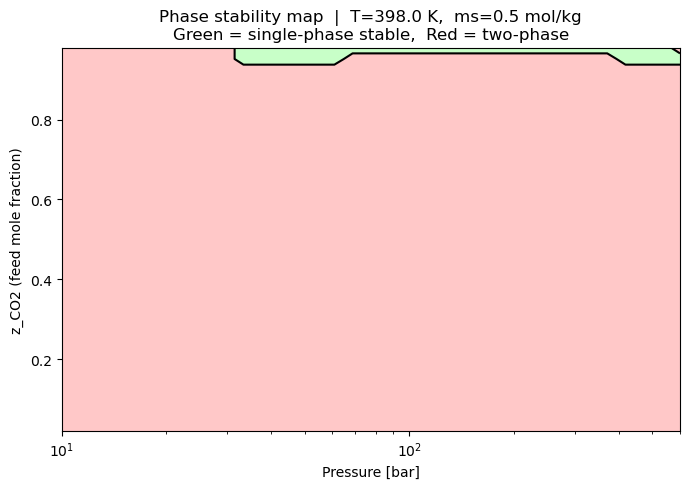

CPU times: user 200 ms, sys: 168 ms, total: 368 ms
Wall time: 46.8 s


In [18]:
%%time
T_map  = 398.0
ms_map = 0.5
P_vals = np.logspace(np.log10(10), np.log10(600), 35)
z_vals = np.linspace(0.02, 0.98, 35)

stable_map = stability_map(z_vals, P_vals, ms_map, T_map, params,
                           n_workers=N_WORKERS)

# Report isolated stable points (no stable neighbours) — likely misclassified
isolated = []
for ii in range(len(z_vals)):
    for jj in range(len(P_vals)):
        if stable_map[ii, jj]:
            neighbors = [
                stable_map[ii+di, jj+dj]
                for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]
                if 0 <= ii+di < len(z_vals) and 0 <= jj+dj < len(P_vals)
            ]
            if not any(neighbors):
                isolated.append((ii, jj))
if isolated:
    print(f"{len(isolated)} isolated stable point(s) — likely misclassified:")
    print(f"  {'z_CO2':>8}  {'P [bar]':>10}")
    for ii, jj in isolated:
        print(f"  {z_vals[ii]:8.4f}  {P_vals[jj]:10.2f}")
else:
    print('No isolated stable points found.')

fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(P_vals, z_vals, stable_map.astype(float),
            levels=[-0.5, 0.5, 1.5], colors=['#ffbbbb', '#bbffbb'], alpha=0.8)
ax.contour(P_vals, z_vals, stable_map.astype(float),
           levels=[0.5], colors=['k'], linewidths=1.5)
ax.set_xscale('log')
ax.set_xlabel('Pressure [bar]')
ax.set_ylabel('z_CO2 (feed mole fraction)')
ax.set_title(f'Phase stability map  |  T={T_map} K,  ms={ms_map} mol/kg\n'
             f'Green = single-phase stable,  Red = two-phase')
plt.tight_layout()
plt.show()


### 7.5  Effect of salinity on the stability boundary

Plot $\Sigma W_{aq}$ (aqueous trial) as a function of P for several salt concentrations at fixed (T, z_CO₂). The aqueous trial uses the salt-dependent aqueous EOS for the trial phase, so it captures the ms-dependence of the stability boundary. The CO₂-rich trial ($\Sigma W_c$) uses the CO₂-rich EOS for both the reference and trial, making it independent of ms by construction.

Expected behaviour with increasing salinity:

- Higher ms → CO₂ less soluble in brine (salting-out) → aqueous phase more easily destabilised → $\Sigma W_{aq} > 1$ over a wider pressure range
- The pressure at which $\Sigma W_{aq} = 1$ marks the stability boundary for the aqueous trial

This salting-out effect is the main reason CO₂ storage in saline aquifers differs from pure-water systems.


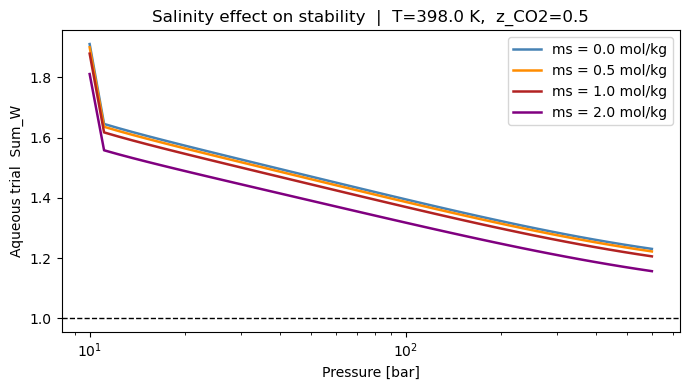

CPU times: user 126 ms, sys: 63.1 ms, total: 189 ms
Wall time: 3.63 s


In [19]:
%%time
T_ms    = 398.0
z_ms    = 0.5
P_ms    = np.logspace(np.log10(10), np.log10(600), 40)
ms_list = [0.0, 0.5, 1.0, 2.0]
colors  = ['steelblue', 'darkorange', 'firebrick', 'purple']

sw_c, sw_aq = stability_ms_scan(ms_list, P_ms, z_ms, T_ms, params, n_workers=N_WORKERS)

# sum_W_c (CO2-rich trial) uses CO2-rich EOS for both reference and trial,
# so it has no ms dependence. The salinity effect is in sum_W_aq (aqueous
# trial), which uses the salt-dependent aqueous EOS for the trial phase.
fig, ax = plt.subplots(figsize=(7, 4))
for idx, (ms_i, col) in enumerate(zip(ms_list, colors)):
    ax.semilogx(P_ms, sw_aq[idx], color=col, lw=1.8, label=f'ms = {ms_i} mol/kg')

ax.axhline(1.0, color='k', ls='--', lw=1)
ax.set_xlabel('Pressure [bar]')
ax.set_ylabel('Aqueous trial  Sum_W')
ax.set_title(f'Salinity effect on stability  |  T={T_ms} K,  z_CO2={z_ms}')
ax.legend()
plt.tight_layout()
plt.show()


---
## Section 8: Solution Table and Fast Flash

For reservoir simulation, millions of flash calls are needed — often for identical (T, P, z, ms) conditions.
The standard SSI flash requires 20–40 ELV solves per call because it starts from ms=0 every time.

**Strategy:** build a dense solution table once (offline), then at runtime:
1. Interpolate the table to get a starting point (sol_guess, ms_aq_guess) already near the answer
2. Run 1–3 SSI iterations from that starting point instead of 20–40 from cold

The table covers (T, P, z_CO₂, ms) on a regular grid (log-spaced in P).
At each converged point the full 10-element ELV solution vector is stored.
Unconverged (single-phase) cells are filled by nearest-neighbour from the nearest two-phase point
so the `RegularGridInterpolator` has no NaN gaps.


### 8.1  Build the solution table

Run `build_solution_table()` once. Results are cached to `results/solution_table.npz`;
subsequent calls load from disk unless `force_recompute=True`.
Grid size: 18 T × 30 P × 19 z × 7 ms ≈ 72,000 flash calculations.


In [ ]:
%%time
from ecpa.solution_table import (
    build_solution_table, load_solution_table,
    make_solution_guess_fn, print_table_summary,
)
from ecpa.flash import flash_co2_h2o_salt_fast, flash_co2_h2o_salt_ssi

grid_data = build_solution_table(
    params      = params,
    CPA_GROUPS  = CPA_GROUPS,
    CPA_TEMPS   = CPA_TEMPS,
    save_path   = 'results/solution_table.npz',
    n_workers   = N_WORKERS,
    force_recompute = False,
)
print_table_summary(grid_data)


### 8.2  Build the interpolator and test a single call

`make_solution_guess_fn()` wraps the table in 11 `RegularGridInterpolator` objects
(one per ELV variable) plus a nearest-neighbour interpolator for the stability flag.
Building the interpolators takes ~1 s; the resulting `guess_fn` object is lightweight
and can be serialised and sent to worker processes.


In [ ]:
%%time
solution_guess_fn = make_solution_guess_fn(grid_data)

# Test: single point
T_test, P_test, z_test, ms_test = 398.0, 100.0, 0.5, 1.0

sol_g, ms_g, is_2ph = solution_guess_fn(T_test, P_test, z_test, ms_test)
print(f'Interpolated guess at T={T_test} K, P={P_test} bar, z={z_test}, ms={ms_test}:')
print(f'  is_two_phase = {is_2ph}')
print(f'  ms_aq_guess  = {ms_g:.6f}')
print(f'  sol_guess    = {sol_g}')


### 8.3  Benchmark fast flash vs standard SSI

Key design decisions validated by profiling:
- The outer ms_aq SSI loop convergence rate is set by the damping factor (ω), not the
  starting point.  Cold-start SSI uses ω=0.7 (safe for divergence) → 11–13 iterations.
- With a table warm-start close to the solution, **ω=1.0 (no damping) is safe** and
  converges in 3–4 iterations — a **3× reduction** in ELV solves.
- `ecpa_stability` costs ~30 ms/call ≈ 5× the warm-started flash itself.  Running it
  unconditionally makes the fast path *slower* than cold SSI.
- **Selective stability**: trust the table hint (`is_two_phase=True`) for clearly
  two-phase cells; run `ecpa_stability` only when the hint is uncertain (single-phase
  or near-boundary cells).  Use `force_stability_check=True` for validation runs.


In [ ]:
%%time
import time

# Test conditions: grid over P at fixed (T, z, ms)
T_bm, z_bm, ms_bm = 398.0, 0.5, 1.0
P_bm = np.logspace(np.log10(20), np.log10(400), 30)

def _run_ssi(label, **kwargs):
    t0 = time.perf_counter()
    results = []
    for P_i in P_bm:
        try:
            out = flash_co2_h2o_salt_ssi(
                T=T_bm, P_bar=P_i, z_co2=z_bm, m_tot=ms_bm,
                guess_table_fn=guess_table_fn, params=params, **kwargs)
            results.append(('ok', out['ms_aq'], out.get('n_iter_ms', -1)))
        except Exception:
            results.append(('fail', float('nan'), -1))
    t = time.perf_counter() - t0
    ok    = sum(1 for r in results if r[0] == 'ok')
    iters = [r[2] for r in results if r[0] == 'ok' and r[2] > 0]
    print(f'{label:<45s} {ok:2d}/{len(P_bm)}  avg_iters={sum(iters)/len(iters):.1f}  {t:.3f}s')
    return results, t

def _run_fast(label, **kwargs):
    t0 = time.perf_counter()
    results = []
    for P_i in P_bm:
        try:
            out = flash_co2_h2o_salt_fast(
                T=T_bm, P_bar=P_i, z_co2=z_bm, m_tot=ms_bm,
                solution_guess_fn=solution_guess_fn, params=params,
                fallback_guess_table_fn=guess_table_fn, **kwargs)
            ms_val = out.get('ms_aq', float('nan')) if out.get('phase') != 'single_phase' else float('nan')
            results.append(('ok', ms_val, out.get('n_iter_ms', 0), out.get('phase', '?')))
        except Exception as e:
            results.append(('fail', float('nan'), -1, 'fail'))
    t = time.perf_counter() - t0
    ok    = sum(1 for r in results if r[0] == 'ok')
    iters = [r[2] for r in results if r[0] == 'ok' and r[2] > 0]
    avg_it = sum(iters)/len(iters) if iters else 0
    print(f'{label:<45s} {ok:2d}/{len(P_bm)}  avg_iters={avg_it:.1f}  {t:.3f}s')
    return results, t

print(f'Benchmark: T={T_bm}K  z={z_bm}  ms={ms_bm}  N={len(P_bm)} pts\n')
print(f'{"Method":<45s} {"conv":>7}  {"avg_it":>9}  {"time":>6}')
print('-' * 70)

r_cold, t_cold = _run_ssi ('Cold SSI (baseline)')
r_fast, t_fast = _run_fast('Fast (table hint + ω=1.0)')
r_safe, t_safe = _run_fast('Fast (table hint + ω=1.0 + force_stability)',
                            force_stability_check=True)

print()
print(f'Speedup fast vs cold:           {t_cold/t_fast:.1f}×')
print(f'Speedup fast+stability vs cold: {t_cold/t_safe:.1f}×')

# Accuracy: ms_aq should match cold SSI to near-machine precision
ms_cold = np.array([r[1] for r in r_cold])
ms_fast = np.array([r[1] for r in r_fast])
ms_safe = np.array([r[1] for r in r_safe])
mask = np.isfinite(ms_cold) & np.isfinite(ms_fast)
if mask.any():
    print(f'\nms_aq max diff (fast vs cold):      {np.max(np.abs(ms_cold[mask] - ms_fast[mask])):.2e}')
mask2 = np.isfinite(ms_cold) & np.isfinite(ms_safe)
if mask2.any():
    print(f'ms_aq max diff (fast+stab vs cold): {np.max(np.abs(ms_cold[mask2] - ms_safe[mask2])):.2e}')


---
## Appendix: Guess Table Visualisation

The guess table provides warm-start ELV (Equilibrium Liquid–Vapour) solutions on a pre-computed (T, P) grid. Without it, the flash solver would need to start from scratch at every (T, P) point, greatly reducing robustness.

The plot shows the stored phase compositions and compressibility factors as functions of T and P — this helps diagnose coverage gaps (grey regions where no initial guess is available, forcing the solver to rely on heuristic fallbacks).

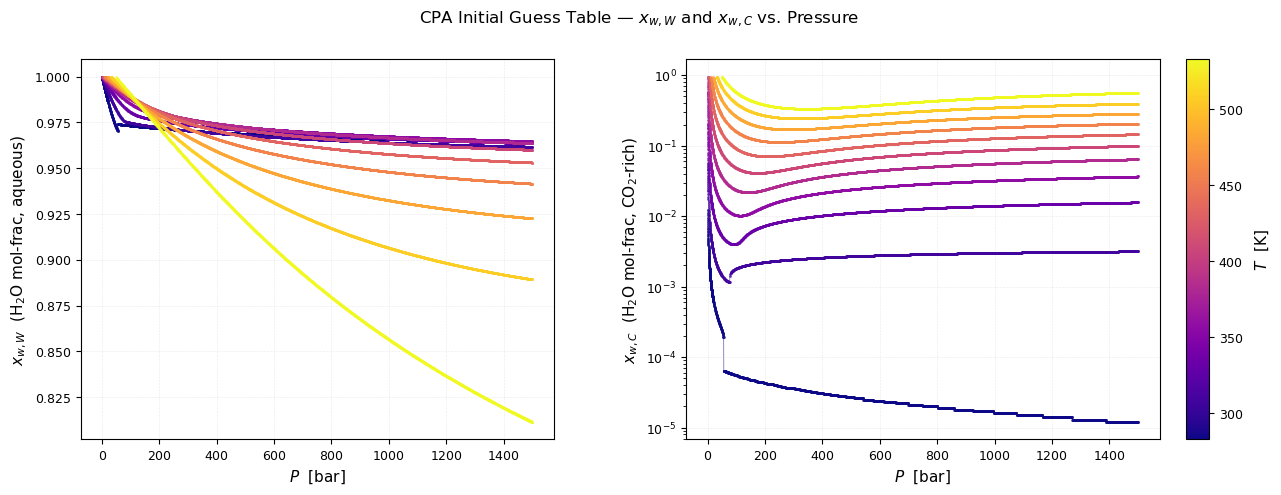

In [20]:
fig_gt = plot_guess_table(
    CPA_GROUPS = CPA_GROUPS,
    CPA_TEMPS  = CPA_TEMPS,
    save_path  = None,
)
plt.show()